# TrackGraph validation with ONNX Runtime inference and performance plots

This notebook reconstructs the tuned TrackGraph model, exports a graph-level ONNX model with **correct duplicate-index aggregation and empty-edge handling**, verifies numerical agreement between PyTorch and ONNX Runtime, and evaluates the selected validation split **using ONNX Runtime predictions**.

**Key changes from `TrackGraph_results.ipynb`**
- Graph-message aggregation is exported with ONNX `ScatterElements(reduction="add")`, preserving PyTorch `index_add` behavior when multiple edges share the same receiver node.
- The ONNX wrapper performs edge-MPNN aggregation without Python shape branches, so graphs with zero edges remain valid dynamic inputs.
- The numerical parity check compares the resulting ONNX model against its PyTorch wrapper before the full validation loop, including an empty-edge graph when present.
- Saved predictions, aggregate metrics, and all plots use ONNX Runtime outputs rather than PyTorch outputs.
- The displayed \(p_T\) / `ptq` target range is fixed to **−90 to 90** in target-based plots.

**Assumptions**
- The converter has already produced HDF5 files containing `/graphs/<id>/x`, `/edge_index`, `/edge_attr`, and `/y_track`.
- The notebook is run from the repository root, alongside `train_TrackGraph.py`.
- The original split `.npz` is available. The checkpoint stores model architecture and target-transform metadata, but not the validation indices.
- The ONNX output is in **physical metric space** in the order `[ptq, eta, phi]`. φ is decoded from the sin/cos head where applicable.

Only edit the configuration cell below before running from top to bottom.


## Configuration

Set `DATA_GLOB` and `SPLIT_FILE` to the same values used for the refit run. `CHECKPOINT_PATH` is prefilled with the requested best refit checkpoint. `MAX_VAL_GRAPHS=None` evaluates the complete validation split.


In [2]:
from pathlib import Path
import glob

# Run the notebook from the TrackGraph repository root, or set this explicitly.
REPO_ROOT = Path.cwd().resolve()

# The notebook imports model, dataset, decoder, and validation helpers from this file.
# The fallback resolver below also recognises the uploaded-name variant.
TRAINER_SCRIPT = REPO_ROOT / "train_TrackGraph.py"

# Update these two paths to your refit inputs.
DATA_GLOB = str(REPO_ROOT / "data" / "track_graphs_pu0_part*.h5")
SPLIT_FILE = REPO_ROOT / "data" / "split_track_graphs_pu0_seed12345.npz"

CHECKPOINT_PATH = (
    REPO_ROOT
    / "tuning_track_graph_smape"
    / "ckpts"
    / "track_graph_regressor_v2_refit_top02_from_t0022.pt"
)

# All notebook outputs are written here; the input checkpoint is never modified.
OUT_DIR = REPO_ROOT / "validation_track_graph_refit_top02_t0022_onnx"
ONNX_PATH = OUT_DIR / f"{CHECKPOINT_PATH.stem}.onnx"
PREDICTIONS_NPZ_PATH = OUT_DIR / f"{CHECKPOINT_PATH.stem}_validation_predictions.npz"
PREDICTIONS_CSV_PATH = OUT_DIR / f"{CHECKPOINT_PATH.stem}_validation_predictions.csv"
METADATA_PATH = OUT_DIR / f"{CHECKPOINT_PATH.stem}_validation_metadata.json"

# Evaluation controls.
MAX_VAL_GRAPHS      = None     # None = entire validation split; otherwise an integer prefix.
PLOT_MAX_POINTS     = 100_000  # Downsample only visualisations, never metric calculation.
PLOT_SEED           = 12345
ONNX_CHECK_GRAPHS   = 16       # Number of non-empty-edge graphs used for ONNX Runtime agreement checks.
PT_PLOT_RANGE      = (-60.0, 60.0)  # Fixed displayed range for ptq target-based plots.
H5_CLOSE_AFTER_READ = False    # Set True for network filesystems where persistent HDF5 handles are unstable.

OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root : {REPO_ROOT}")
print(f"Checkpoint      : {CHECKPOINT_PATH}")
print(f"Validation split: {SPLIT_FILE}")
print(f"Output directory: {OUT_DIR}")

Repository root : /eos/project-f/fcc-ml/ddicroce/ATLAS_MuonSpectrometer/KubeFlow/MuonMLTracking
Checkpoint      : /eos/project-f/fcc-ml/ddicroce/ATLAS_MuonSpectrometer/KubeFlow/MuonMLTracking/tuning_track_graph_smape/ckpts/track_graph_regressor_v2_refit_top02_from_t0022.pt
Validation split: /eos/project-f/fcc-ml/ddicroce/ATLAS_MuonSpectrometer/KubeFlow/MuonMLTracking/data/split_track_graphs_pu0_seed12345.npz
Output directory: /eos/project-f/fcc-ml/ddicroce/ATLAS_MuonSpectrometer/KubeFlow/MuonMLTracking/validation_track_graph_refit_top02_t0022_onnx


## Imports and trainer-module loading

The model is imported directly from the training script so the deployed architecture stays exactly aligned with the checkpoint. The cell does not run the trainer's `main()` function.

In [3]:
import copy
import importlib.util
import json
import math
import os
import sys
import types
from typing import Dict, Iterable, Tuple

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

# `wandb` is only needed by train_TrackGraph.py when training. A tiny import-time stub
# lets this notebook reuse the model/data definitions in environments without wandb.
try:
    import wandb  # noqa: F401
except ImportError:
    sys.modules["wandb"] = types.SimpleNamespace()

if not TRAINER_SCRIPT.exists():
    candidates = [
        REPO_ROOT / "train_TrackGraph.py",
        REPO_ROOT / "train_TrackGraph_v2.py",
        REPO_ROOT / "train_TrackGraph(1).py",
    ]
    existing = [p for p in candidates if p.exists()]
    if not existing:
        raise FileNotFoundError(
            "Could not find the trainer script. Set TRAINER_SCRIPT in the configuration cell."
        )
    TRAINER_SCRIPT = existing[0]

module_name = "trackgraph_trainer_for_validation"
spec = importlib.util.spec_from_file_location(module_name, TRAINER_SCRIPT)
if spec is None or spec.loader is None:
    raise ImportError(f"Cannot import trainer module from {TRAINER_SCRIPT}")
trainer = importlib.util.module_from_spec(spec)
sys.modules[module_name] = trainer
spec.loader.exec_module(trainer)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Imported: {TRAINER_SCRIPT}")
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")

Imported: /eos/project-f/fcc-ml/ddicroce/ATLAS_MuonSpectrometer/KubeFlow/MuonMLTracking/train_TrackGraph.py
PyTorch : 2.7.0+cpu
Device  : cpu


# Inference

## Load the checkpoint and reconstruct the model

The checkpoint metadata controls the model family, dimensions, Fourier encoding, pooling, φ head, and target scaling. `strict=True` deliberately fails if the trainer code and checkpoint are not compatible.

In [3]:
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT_PATH}\n"
        "Set CHECKPOINT_PATH in the configuration cell."
    )

try:
    checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
except TypeError:  # PyTorch versions before weights_only was introduced
    checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")

required_ckpt_keys = {
    "model_state", "xdim", "edim", "hidden_dim", "layers", "dropout",
    "layer_type", "gat_heads", "sage_aggr", "edgeconv_aggr", "graph_pool",
    "fourier", "fourier_base", "fourier_min_exp", "fourier_max_exp",
    "phi_mode", "phi_period", "target_center_linear", "target_scale_linear",
}
missing = sorted(required_ckpt_keys.difference(checkpoint))
if missing:
    raise KeyError(f"Checkpoint is missing required metadata: {missing}")

model = trainer.TrackGraphRegressorGNN(
    xdim=int(checkpoint["xdim"]),
    edim=int(checkpoint["edim"]),
    hdim=int(checkpoint["hidden_dim"]),
    n_layers=int(checkpoint["layers"]),
    dropout=float(checkpoint["dropout"]),
    layer_type=str(checkpoint["layer_type"]),
    gat_heads=int(checkpoint["gat_heads"]),
    sage_aggr=str(checkpoint["sage_aggr"]),
    edgeconv_aggr=str(checkpoint["edgeconv_aggr"]),
    use_fourier=bool(checkpoint["fourier"]),
    fourier_base=float(checkpoint["fourier_base"]),
    fourier_min_exp=int(checkpoint["fourier_min_exp"]),
    fourier_max_exp=int(checkpoint["fourier_max_exp"]),
    graph_pool=str(checkpoint["graph_pool"]),
    phi_mode=str(checkpoint["phi_mode"]),
)
model.load_state_dict(checkpoint["model_state"], strict=True)
model = model.to(DEVICE).eval()

target_center = torch.as_tensor(
    checkpoint["target_center_linear"], dtype=torch.float32, device=DEVICE
).reshape(2)
target_scale = torch.as_tensor(
    checkpoint["target_scale_linear"], dtype=torch.float32, device=DEVICE
).reshape(2)
phi_mode = str(checkpoint["phi_mode"])
phi_period = float(checkpoint["phi_period"])

model_summary_keys = [
    "run_id", "epoch", "best_ckpt_epoch", "best_monitor", "early_stop_monitor",
    "xdim", "edim", "hidden_dim", "layers", "dropout", "layer_type",
    "gat_heads", "sage_aggr", "edgeconv_aggr", "graph_pool", "fourier",
    "fourier_base", "fourier_min_exp", "fourier_max_exp", "phi_mode", "phi_period",
    "target_scale_mode", "target_center_linear", "target_scale_linear",
]
model_summary = pd.DataFrame(
    [{"field": key, "value": checkpoint.get(key)} for key in model_summary_keys]
)
display(model_summary)

,field,value
0,run_id,refit_top02_from_t0022
1,epoch,191
2,best_ckpt_epoch,191
3,best_monitor,0.097031
4,early_stop_monitor,val_loss
5,xdim,10
6,edim,7
7,hidden_dim,256
8,layers,3
9,dropout,0.116503


## Load and verify the validation split

The graph ordering is important. The trainer indexes all HDF5 graphs in sorted file order, then applies `val_idx` from the split. This cell repeats that logic and rejects a split written for a different HDF5 list.

In [4]:
h5_paths = sorted(glob.glob(DATA_GLOB))
if not h5_paths:
    raise FileNotFoundError(
        f"DATA_GLOB matched no HDF5 files: {DATA_GLOB}\n"
        "Set DATA_GLOB in the configuration cell."
    )
if not SPLIT_FILE.exists():
    raise FileNotFoundError(
        f"Split file not found: {SPLIT_FILE}\n"
        "Set SPLIT_FILE in the configuration cell."
    )

split = np.load(SPLIT_FILE, allow_pickle=True)
if "val_idx" not in split.files:
    raise KeyError(f"Expected 'val_idx' in {SPLIT_FILE}; found {split.files}")

val_idx = split["val_idx"].astype(np.int64)
if val_idx.size == 0:
    raise RuntimeError("The validation split is empty.")

def h5_logical_id(path: str) -> str:
    """
    Compare HDF5 files independently of the EOS project mount alias.

    Both of these become the same logical ID:
      /eos/project-i01/f/fcc-ml/...
      /eos/project-f/fcc-ml/...
    """
    path = Path(str(path)).as_posix()

    marker = "/fcc-ml/"
    if marker in path:
        return marker + path.split(marker, 1)[1]

    # Fall back to the complete path if this is not an expected EOS path.
    return path


current_h5_paths = [str(Path(p)) for p in h5_paths]

if "h5_paths" in split.files:
    saved_h5_paths = [str(p) for p in split["h5_paths"].tolist()]

    saved_h5_ids = [h5_logical_id(p) for p in saved_h5_paths]
    current_h5_ids = [h5_logical_id(p) for p in current_h5_paths]

    if saved_h5_ids != current_h5_ids:
        first_bad = next(
            i for i, (saved, current) in enumerate(
                zip(saved_h5_ids, current_h5_ids)
            )
            if saved != current
        )
        raise RuntimeError(
            "The split file was created for a different HDF5 file list or ordering.\n"
            f"First mismatch at file index {first_bad}:\n"
            f"Saved:   {saved_h5_paths[first_bad]}\n"
            f"Current: {current_h5_paths[first_bad]}"
        )

    if saved_h5_paths != current_h5_paths:
        print(
            "[warn] Split-file HDF5 paths use a different EOS mount alias, "
            "but their logical paths and ordering match. Proceeding."
        )

dataset = trainer.H5TrackGraphDataset(
    h5_paths,
    h5_close_after_read=H5_CLOSE_AFTER_READ,
)
if val_idx.min() < 0 or val_idx.max() >= len(dataset):
    raise IndexError(
        f"Validation indices are out of range for current dataset: "
        f"min={val_idx.min()}, max={val_idx.max()}, total={len(dataset)}"
    )

if MAX_VAL_GRAPHS is not None:
    if int(MAX_VAL_GRAPHS) <= 0:
        raise ValueError("MAX_VAL_GRAPHS must be None or a positive integer.")
    eval_idx = val_idx[: int(MAX_VAL_GRAPHS)]
else:
    eval_idx = val_idx

print(f"HDF5 files             : {len(h5_paths)}")
print(f"Total indexed graphs    : {len(dataset):,}")
print(f"Validation split graphs : {len(val_idx):,}")
print(f"Graphs to evaluate      : {len(eval_idx):,}")

# One early compatibility check gives a clearer failure than a long evaluation.
first_graph = dataset[int(eval_idx[0])]
trainer.validate_graph_batch(first_graph, where="notebook/first_validation_graph")
if first_graph["x"].shape[1] != int(checkpoint["xdim"]):
    raise RuntimeError(
        f"x feature mismatch: HDF5 has {first_graph['x'].shape[1]}, "
        f"checkpoint expects {checkpoint['xdim']}"
    )
if first_graph["edge_attr"].shape[1] != int(checkpoint["edim"]):
    raise RuntimeError(
        f"edge_attr feature mismatch: HDF5 has {first_graph['edge_attr'].shape[1]}, "
        f"checkpoint expects {checkpoint['edim']}"
    )
print(
    "First validation graph: "
    f"nodes={first_graph['x'].shape[0]}, edges={first_graph['edge_index'].shape[1]}, "
    f"x_dim={first_graph['x'].shape[1]}, edge_dim={first_graph['edge_attr'].shape[1]}"
)

[warn] Split-file HDF5 paths use a different EOS mount alias, but their logical paths and ordering match. Proceeding.
HDF5 files             : 134
Total indexed graphs    : 1,330,751
Validation split graphs : 133,075
Graphs to evaluate      : 133,075
First validation graph: nodes=5, edges=15, x_dim=10, edge_dim=7


## Export a dynamic-graph ONNX model with duplicate-index-safe aggregation

TrackGraph message passing aggregates edge messages into receiver nodes. Multiple edges can share a receiver index, so PyTorch's `index_add` must be exported as an **additive** scatter operation. The default legacy ONNX exporter warns that duplicate indices are unsupported and can silently overwrite messages, causing large PyTorch–ONNX discrepancies.

The custom symbolic below exports this operation as `ScatterElements(reduction="add")` (supported from ONNX opset 16). The model uses opset 17 and retains dynamic node and edge dimensions.


In [5]:
class MetricSpaceONNXWrapper(torch.nn.Module):
    """ONNX-safe, metric-space wrapper for the checkpoint's edge-MPNN model.

    The trainer's regular forward path contains Python branches for `E == 0` and
    `N == 0`. A legacy ONNX trace turns those Tensor-dependent conditions into
    constants from the example graph. This wrapper implements the evaluated
    edge-MPNN path directly with operations that are valid when `num_edges == 0`:
    gather, MLP, and additive scatter all naturally accept empty first dimensions.

    The dataset contract already rejects graphs with zero nodes, so graph pooling
    remains a standard mean/max reduction over one or more nodes.
    """

    def __init__(
        self,
        base_model: torch.nn.Module,
        center: torch.Tensor,
        scale: torch.Tensor,
        phi_mode: str,
    ):
        super().__init__()
        if str(base_model.layer_type) != "mpnn":
            raise NotImplementedError(
                "The ONNX-safe wrapper below implements the checkpoint's edge-MPNN "
                f"path, but this checkpoint has layer_type={base_model.layer_type!r}."
            )

        self.base_model = base_model
        self.register_buffer("target_center", center.detach().clone().reshape(2))
        self.register_buffer("target_scale", scale.detach().clone().reshape(2))
        self.phi_mode = str(phi_mode)
        self.graph_pool = str(base_model.graph_pool)

    @staticmethod
    def _run_edge_mpnn_layer(
        layer: torch.nn.Module,
        h: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
    ) -> torch.Tensor:
        """Run one EdgeMPNNLayer without Tensor-to-Python branching.

        For zero edges, `src`, `dst`, and `m` have shape `[0]`, `[0]`, and
        `[0, hidden_dim]`. Additive index reduction therefore leaves the
        zero-initialised aggregation unchanged, exactly matching the trainer's
        explicit empty-edge branch.
        """
        src = edge_index[0]
        dst = edge_index[1]
        h_src = h[src]
        h_dst = h[dst]
        messages = layer.edge_mlp(torch.cat([h_src, h_dst, edge_attr], dim=1))

        # `index_add` is registered below as duplicate-index-safe ONNX
        # ScatterElements(reduction="add"). h and messages share hidden_dim.
        aggregated = torch.zeros_like(h).index_add(0, dst, messages.to(dtype=h.dtype))
        update = layer.node_mlp(torch.cat([h, aggregated], dim=1))
        return layer.norm(h + update)

    def _pool_nonempty_graph(self, h: torch.Tensor) -> torch.Tensor:
        # H5TrackGraphDataset validates x.shape[0] > 0. Avoiding the trainer's
        # `if h.size(0) == 0` removes another trace-time Tensor boolean.
        if self.graph_pool == "mean":
            return h.mean(dim=0, keepdim=True)
        if self.graph_pool == "max":
            return h.max(dim=0, keepdim=True).values
        if self.graph_pool == "meanmax":
            return torch.cat(
                [h.mean(dim=0, keepdim=True), h.max(dim=0, keepdim=True).values],
                dim=1,
            )
        raise ValueError(f"Unsupported graph_pool={self.graph_pool!r}")

    def forward(
        self,
        x: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
    ) -> torch.Tensor:
        if self.base_model.fourier is not None:
            x = self.base_model.fourier(x)

        h = self.base_model.node_enc(x)
        for layer in self.base_model.layers:
            h = self._run_edge_mpnn_layer(layer, h, edge_index, edge_attr)

        pooled = self._pool_nonempty_graph(h)
        pt = self.base_model.head_pt(pooled).squeeze(0).squeeze(-1)
        eta = self.base_model.head_eta(pooled).squeeze(0).squeeze(-1)
        phi_raw = self.base_model.head_phi(pooled).squeeze(0)

        ptq = pt * self.target_scale[0] + self.target_center[0]
        eta = eta * self.target_scale[1] + self.target_center[1]
        if self.phi_mode == "sincos":
            phi = torch.atan2(phi_raw[0], phi_raw[1])
        else:
            phi = phi_raw.reshape(-1)[0]

        return torch.stack((ptq, eta, phi), dim=0)


def _constant_scalar(value, name: str) -> float:
    """Read an ONNX-export scalar argument that is expected to be compile-time constant."""
    from torch.onnx import symbolic_helper

    for kind in ("f", "i"):
        try:
            return float(symbolic_helper._get_const(value, kind, name))
        except (RuntimeError, TypeError, ValueError):
            pass
    raise RuntimeError(f"Expected a constant scalar for {name} during ONNX export.")


def _index_add_to_reduction_scatter(g, self, dim, index, source, alpha=None):
    """Export tensor.index_add(dim=0) with duplicate-safe additive semantics.

    TrackGraph aggregates edge messages of shape `[num_edges, hidden_dim]` at
    receiver-node indices. The index vector is expanded over `hidden_dim` because
    ONNX ScatterElements requires `indices.shape == updates.shape`.
    """
    from torch.onnx import symbolic_helper

    dim_value = int(symbolic_helper._get_const(dim, "i", "dim"))
    if dim_value != 0:
        raise RuntimeError(
            "The duplicate-safe ONNX index_add exporter currently supports dim=0 only; "
            f"received dim={dim_value}."
        )

    source_shape = g.op("Shape", source)

    # In ONNX opset >= 13, Unsqueeze receives `axes` as a required int64
    # tensor input. The pre-opset-13 attribute form is not valid here and
    # produces a model that fails ONNX schema validation under opset 17.
    axes = g.op(
        "Constant",
        value_t=torch.tensor([1], dtype=torch.int64),
    )
    index_column = g.op("Unsqueeze", index, axes)
    expanded_index = g.op("Expand", index_column, source_shape)

    if alpha is not None:
        alpha_value = _constant_scalar(alpha, "alpha")
        if alpha_value != 1.0:
            alpha_tensor = g.op(
                "Constant",
                value_t=torch.tensor(alpha_value, dtype=torch.float32),
            )
            source = g.op("Mul", source, alpha_tensor)

    return g.op(
        "ScatterElements",
        self,
        expanded_index,
        source,
        axis_i=0,
        reduction_s="add",
    )


# Register both variants. The wrapper uses out-of-place index_add, while this
# also covers older PyTorch traces that retain the in-place spelling.
torch.onnx.register_custom_op_symbolic(
    "aten::index_add", _index_add_to_reduction_scatter, 17
)
torch.onnx.register_custom_op_symbolic(
    "aten::index_add_", _index_add_to_reduction_scatter, 17
)


def first_nonempty_edge_graph(indices: Iterable[int]) -> Dict[str, object]:
    for global_index in indices:
        graph = dataset[int(global_index)]
        if int(graph["edge_index"].shape[1]) > 0:
            return graph
    raise RuntimeError(
        "No validation graph has an edge. Export needs one non-empty-edge example "
        "to retain the message-passing and additive-scatter operations."
    )


export_example_graph = first_nonempty_edge_graph(eval_idx)
example_args = (
    export_example_graph["x"].float().cpu().contiguous(),
    export_example_graph["edge_index"].long().cpu().contiguous(),
    export_example_graph["edge_attr"].float().cpu().contiguous(),
)

export_model = MetricSpaceONNXWrapper(
    copy.deepcopy(model).cpu().eval(),
    target_center.detach().cpu(),
    target_scale.detach().cpu(),
    phi_mode,
).eval()

onnx_export_kwargs = {
    "opset_version": 17,
    "do_constant_folding": True,
    "input_names": ["x", "edge_index", "edge_attr"],
    "output_names": ["prediction"],
    "dynamic_axes": {
        "x": {0: "num_nodes"},
        "edge_index": {1: "num_edges"},
        "edge_attr": {0: "num_edges"},
    },
}

try:
    torch.onnx.export(
        export_model,
        example_args,
        str(ONNX_PATH),
        dynamo=False,
        **onnx_export_kwargs,
    )
except TypeError:
    # Compatibility path for older PyTorch releases without the `dynamo` argument.
    torch.onnx.export(export_model, example_args, str(ONNX_PATH), **onnx_export_kwargs)

dataset._close_files()
print(f"Exported duplicate-index-safe and empty-edge-safe ONNX model: {ONNX_PATH}")


Exported duplicate-index-safe and empty-edge-safe ONNX model: /eos/project-f/fcc-ml/ddicroce/ATLAS_MuonSpectrometer/KubeFlow/MuonMLTracking/validation_track_graph_refit_top02_t0022_onnx/track_graph_regressor_v2_refit_top02_from_t0022.onnx


## Validate the ONNX file and compare ONNX Runtime with PyTorch

This validates the ONNX graph structurally, then compares metric-space predictions on representative validation graphs. The parity set always includes a non-empty-edge graph and, when available, an empty-edge graph. This confirms that the exported model retains correct duplicate-index aggregation and has not frozen the trainer’s empty-edge branch from the export example.


In [6]:
try:
    import onnx
    import onnxruntime as ort
except ImportError as exc:
    raise ImportError(
        "ONNX verification needs `onnx` and `onnxruntime`. "
        "Install them with: %pip install -U onnx onnxruntime"
    ) from exc

onnx_model = onnx.load(str(ONNX_PATH))
onnx.checker.check_model(str(ONNX_PATH))

available_providers = ort.get_available_providers()
session = ort.InferenceSession(
    str(ONNX_PATH),
    providers=["CPUExecutionProvider"],
)


def to_ort_inputs(graph: Dict[str, object]) -> Dict[str, np.ndarray]:
    """Convert a graph dictionary to contiguous ONNX Runtime CPU inputs."""
    return {
        "x": np.ascontiguousarray(
            graph["x"].detach().cpu().numpy(), dtype=np.float32
        ),
        "edge_index": np.ascontiguousarray(
            graph["edge_index"].detach().cpu().numpy(), dtype=np.int64
        ),
        "edge_attr": np.ascontiguousarray(
            graph["edge_attr"].detach().cpu().numpy(), dtype=np.float32
        ),
    }


def select_parity_indices(indices: Iterable[int], max_graphs: int):
    """Cover both edge regimes, then fill remaining parity slots in split order."""
    first_nonempty = None
    first_empty = None
    ordered = [int(i) for i in indices]

    for global_index in ordered:
        graph = dataset[global_index]
        if int(graph["edge_index"].shape[1]) == 0:
            if first_empty is None:
                first_empty = global_index
        elif first_nonempty is None:
            first_nonempty = global_index
        if first_nonempty is not None and first_empty is not None:
            break

    selected = []
    for candidate in (first_nonempty, first_empty):
        if candidate is not None and candidate not in selected:
            selected.append(candidate)

    for global_index in ordered:
        if global_index not in selected:
            selected.append(global_index)
        if len(selected) >= max_graphs:
            break

    return selected, (first_empty is not None)


# Always reserve room for both non-empty and empty-edge parity cases when the
# split contains them; the model was exported with a non-empty trace example.
parity_indices, validation_has_empty_edge_graph = select_parity_indices(
    eval_idx,
    max(2, int(ONNX_CHECK_GRAPHS)),
)
if not parity_indices:
    raise RuntimeError("The validation split is empty; cannot validate ONNX Runtime parity.")

absolute_differences = []
parity_edge_counts = []
with torch.inference_mode():
    for global_index in parity_indices:
        graph = dataset[int(global_index)]
        args_cpu = (
            graph["x"].float().cpu().contiguous(),
            graph["edge_index"].long().cpu().contiguous(),
            graph["edge_attr"].float().cpu().contiguous(),
        )
        torch_output = export_model(*args_cpu).detach().cpu().numpy()
        onnx_output = session.run(["prediction"], to_ort_inputs(graph))[0]

        np.testing.assert_allclose(
            onnx_output,
            torch_output,
            rtol=1e-4,
            atol=2e-5,
            err_msg=f"PyTorch/ONNX mismatch for dataset index {int(global_index)}",
        )
        absolute_differences.append(float(np.max(np.abs(onnx_output - torch_output))))
        parity_edge_counts.append(int(graph["edge_index"].shape[1]))

dataset._close_files()

graphs_checked = len(parity_indices)
checked_empty_edge_graph = any(count == 0 for count in parity_edge_counts)

print("ONNX model passes structural validation and PyTorch parity checks.")
print(f"ONNX Runtime providers available: {available_providers}")
print(f"Graphs compared              : {graphs_checked}")
print(f"Includes an empty-edge graph : {checked_empty_edge_graph}")
print(f"Largest |ONNX − PyTorch|    : {max(absolute_differences):.3e}")
if validation_has_empty_edge_graph and not checked_empty_edge_graph:
    raise AssertionError(
        "The validation split contains an empty-edge graph, but the parity set did not test one."
    )


ONNX model passes structural validation and PyTorch parity checks.
ONNX Runtime providers available: ['AzureExecutionProvider', 'CPUExecutionProvider']
Graphs compared              : 16
Includes an empty-edge graph : False
Largest |ONNX − PyTorch|    : 1.335e-05


## Run validation inference in ONNX Runtime metric space

The entire selected validation split is evaluated through the ONNX Runtime session. The `y_pred` array created here is the single prediction source used by the metrics, exported result tables, and performance plots below.

The φ residual is wrapped into `[-period/2, period/2)` before metrics are calculated, matching the trainer's angle-aware metric logic.


In [7]:
def wrapped_angle_residual(
    pred_phi: np.ndarray,
    true_phi: np.ndarray,
    period: float,
) -> np.ndarray:
    half_period = 0.5 * float(period)
    return np.remainder(pred_phi - true_phi + half_period, period) - half_period

pred_rows = []
truth_rows = []
graph_indices = []

for global_index in tqdm(eval_idx, desc="ONNX Runtime validation inference", unit="graph"):
    graph = dataset[int(global_index)]
    trainer.validate_graph_batch(graph, where="notebook/onnx_validation")

    onnx_prediction = session.run(["prediction"], to_ort_inputs(graph))[0]
    pred_rows.append(np.asarray(onnx_prediction, dtype=np.float64).reshape(3))
    truth_rows.append(graph["y_track"].detach().cpu().numpy().astype(np.float64))
    graph_indices.append(int(global_index))

dataset._close_files()

y_pred = np.vstack(pred_rows)  # ONNX Runtime predictions, in [ptq, eta, phi] metric space.
y_true = np.vstack(truth_rows)
graph_indices = np.asarray(graph_indices, dtype=np.int64)

residual = y_pred - y_true
residual[:, 2] = wrapped_angle_residual(y_pred[:, 2], y_true[:, 2], phi_period)
abs_error = np.abs(residual)
smape = 200.0 * abs_error / np.clip(np.abs(y_pred) + np.abs(y_true), 1e-6, None)
ptq_mape = 100.0 * abs_error[:, 0] / np.clip(np.abs(y_true[:, 0]), 1e-6, None)

print(f"Completed ONNX Runtime predictions for {len(y_true):,} validation graphs.")
print(f"Prediction array shape: {y_pred.shape}")


ONNX Runtime validation inference:   0%|          | 0/133075 [00:00<?, ?graph/s]

Completed ONNX Runtime predictions for 133,075 validation graphs.
Prediction array shape: (133075, 3)


## Save ONNX Runtime predictions and report aggregate validation metrics


In [8]:
target_names = ["ptq", "eta", "phi"]

metric_rows = []
for col, name in enumerate(target_names):
    row = {
        "target": name,
        "MAE": float(abs_error[:, col].mean()),
        "median_AE": float(np.median(abs_error[:, col])),
        "p90_AE": float(np.quantile(abs_error[:, col], 0.90)),
        "RMSE": float(np.sqrt(np.mean(residual[:, col] ** 2))),
        "mean_SMAPE_percent": float(smape[:, col].mean()),
    }
    if name == "ptq":
        row["mean_MAPE_percent"] = float(ptq_mape.mean())
    metric_rows.append(row)

metrics = pd.DataFrame(metric_rows)
display(metrics)

predictions_table = pd.DataFrame(
    {
        "dataset_index": graph_indices,
        "true_ptq": y_true[:, 0],
        "pred_ptq": y_pred[:, 0],
        "residual_ptq": residual[:, 0],
        "smape_ptq_percent": smape[:, 0],
        "ptq_mape_percent": ptq_mape,
        "true_eta": y_true[:, 1],
        "pred_eta": y_pred[:, 1],
        "residual_eta": residual[:, 1],
        "smape_eta_percent": smape[:, 1],
        "true_phi": y_true[:, 2],
        "pred_phi": y_pred[:, 2],
        "wrapped_residual_phi": residual[:, 2],
        "smape_phi_percent": smape[:, 2],
    }
)

np.savez_compressed(
    PREDICTIONS_NPZ_PATH,
    dataset_index=graph_indices,
    y_true=y_true,
    y_pred=y_pred,
    residual=residual,
    smape_percent=smape,
    ptq_mape_percent=ptq_mape,
    target_names=np.asarray(target_names),
    phi_period=np.asarray(phi_period),
)
predictions_table.to_csv(PREDICTIONS_CSV_PATH, index=False)

metadata = {
    "inference_backend": "onnxruntime",
    "onnx_model": str(ONNX_PATH.resolve()),
    "onnx_parity_graphs_checked": int(graphs_checked),
    "onnx_parity_max_abs_difference": float(max(absolute_differences)),
    "checkpoint": str(CHECKPOINT_PATH.resolve()),
    "trainer_script": str(TRAINER_SCRIPT.resolve()),
    "data_glob": DATA_GLOB,
    "split_file": str(SPLIT_FILE.resolve()),
    "n_h5_files": len(h5_paths),
    "n_validation_graphs_in_split": int(len(val_idx)),
    "n_validation_graphs_evaluated": int(len(eval_idx)),
    "target_names": target_names,
    "phi_period": phi_period,
    "phi_mode": phi_mode,
    "metrics": metrics.to_dict(orient="records"),
}
METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Prediction source      : ONNX Runtime")
print(f"Saved metrics metadata : {METADATA_PATH}")
print(f"Saved predictions (.npz): {PREDICTIONS_NPZ_PATH}")
print(f"Saved predictions (.csv): {PREDICTIONS_CSV_PATH}")

,target,MAE,median_AE,p90_AE,RMSE,mean_SMAPE_percent,mean_MAPE_percent
0,ptq,5.435811,2.489994,10.809305,12.822011,14.971409,14.50363
1,eta,0.019199,0.017301,0.035063,0.025717,3.367209,NaN
2,phi,0.018742,0.013287,0.037375,0.031178,3.106878,NaN


Prediction source      : ONNX Runtime
Saved metrics metadata : /eos/project-f/fcc-ml/ddicroce/ATLAS_MuonSpectrometer/KubeFlow/MuonMLTracking/validation_track_graph_refit_top02_t0022_onnx/track_graph_regressor_v2_refit_top02_from_t0022_validation_metadata.json
Saved predictions (.npz): /eos/project-f/fcc-ml/ddicroce/ATLAS_MuonSpectrometer/KubeFlow/MuonMLTracking/validation_track_graph_refit_top02_t0022_onnx/track_graph_regressor_v2_refit_top02_from_t0022_validation_predictions.npz
Saved predictions (.csv): /eos/project-f/fcc-ml/ddicroce/ATLAS_MuonSpectrometer/KubeFlow/MuonMLTracking/validation_track_graph_refit_top02_t0022_onnx/track_graph_regressor_v2_refit_top02_from_t0022_validation_predictions.csv


# Performance plots

All aggregate metrics and plots below use the ONNX Runtime `y_pred` array. The plots can use a deterministic downsample to remain responsive for very large validation sets.


## Loading data

In [4]:
# Plot-only reload: run this cell after the configuration cell to reuse the
# predictions and labels saved by the ONNX Runtime validation run.
# No model, HDF5 dataset, ONNX export, or ONNX Runtime session is needed here.
from pathlib import Path
import numpy as np

CHECKPOINT_PATH = Path.cwd().resolve() / "tuning_track_graph_smape" / "ckpts" / "track_graph_regressor_v2_refit_top02_from_t0022.pt"
OUT_DIR = Path.cwd().resolve() / "validation_track_graph_refit_top02_t0022_onnx"
PREDICTIONS_NPZ_PATH = OUT_DIR / f"{CHECKPOINT_PATH.stem}_validation_predictions.npz"
PLOT_SEED = 12345
PLOT_MAX_POINTS = 100_000
PT_PLOT_RANGE = (-60.0, 60.0)

if "PREDICTIONS_NPZ_PATH" not in globals():
    raise NameError(
        "PREDICTIONS_NPZ_PATH is not defined. Run the notebook configuration cell first."
    )

prediction_cache = Path(PREDICTIONS_NPZ_PATH)
if not prediction_cache.exists():
    raise FileNotFoundError(
        f"Saved ONNX prediction cache not found: {prediction_cache}\n"
        "Run the ONNX Runtime validation and save-results cells once to create it."
    )

required_cache_keys = {
    "dataset_index",
    "y_true",
    "y_pred",
    "residual",
    "smape_percent",
    "ptq_mape_percent",
    "target_names",
    "phi_period",
}
with np.load(prediction_cache, allow_pickle=False) as saved:
    missing_cache_keys = sorted(required_cache_keys.difference(saved.files))
    if missing_cache_keys:
        raise KeyError(
            f"Prediction cache is missing required arrays: {missing_cache_keys}. "
            "Regenerate it by running the ONNX validation and save-results cells."
        )

    graph_indices = np.asarray(saved["dataset_index"], dtype=np.int64)
    y_true = np.asarray(saved["y_true"], dtype=np.float64)
    y_pred = np.asarray(saved["y_pred"], dtype=np.float64)
    residual = np.asarray(saved["residual"], dtype=np.float64)
    smape = np.asarray(saved["smape_percent"], dtype=np.float64)
    ptq_mape = np.asarray(saved["ptq_mape_percent"], dtype=np.float64)
    target_names = [str(name) for name in np.asarray(saved["target_names"]).tolist()]
    phi_period = float(np.asarray(saved["phi_period"]).reshape(()))

if y_true.ndim != 2 or y_pred.ndim != 2 or y_true.shape != y_pred.shape:
    raise ValueError(
        "Cached y_true and y_pred must be matching 2-D arrays; "
        f"got y_true={y_true.shape}, y_pred={y_pred.shape}."
    )
if y_true.shape[1] != len(target_names):
    raise ValueError(
        "Cached target_names do not match the prediction-column count: "
        f"{len(target_names)} names for {y_true.shape[1]} columns."
    )
if graph_indices.shape[0] != y_true.shape[0]:
    raise ValueError(
        "Cached dataset_index length does not match the number of predictions: "
        f"{graph_indices.shape[0]} versus {y_true.shape[0]}."
    )

# Recreate the deterministic visualisation sample used by every plot below.
rng = np.random.default_rng(PLOT_SEED)
if len(y_true) > PLOT_MAX_POINTS:
    plot_idx = np.sort(rng.choice(len(y_true), size=PLOT_MAX_POINTS, replace=False))
else:
    plot_idx = np.arange(len(y_true))

print(f"Loaded cached ONNX Runtime results: {prediction_cache}")
print(f"Cached prediction shape          : {y_pred.shape}")
print(f"Plotting {len(plot_idx):,} of {len(y_true):,} cached validation graphs.")


Loaded cached ONNX Runtime results: /eos/project-f/fcc-ml/ddicroce/ATLAS_MuonSpectrometer/KubeFlow/MuonMLTracking/validation_track_graph_refit_top02_t0022_onnx/track_graph_regressor_v2_refit_top02_from_t0022_validation_predictions.npz
Cached prediction shape          : (133075, 3)
Plotting 100,000 of 133,075 cached validation graphs.


In [5]:
rng = np.random.default_rng(PLOT_SEED)
if len(y_true) > PLOT_MAX_POINTS:
    plot_idx = np.sort(rng.choice(len(y_true), size=PLOT_MAX_POINTS, replace=False))
else:
    plot_idx = np.arange(len(y_true))

print(f"Plotting {len(plot_idx):,} of {len(y_true):,} validation graphs.")

Plotting 100,000 of 133,075 validation graphs.


### ONNX Runtime prediction versus target

The diagonal is the ideal prediction. For φ, the displayed values are principal-angle values and the separate residual plots below use circular (wrapped) errors. The displayed `ptq` range is fixed to −90 to 90 on both axes.


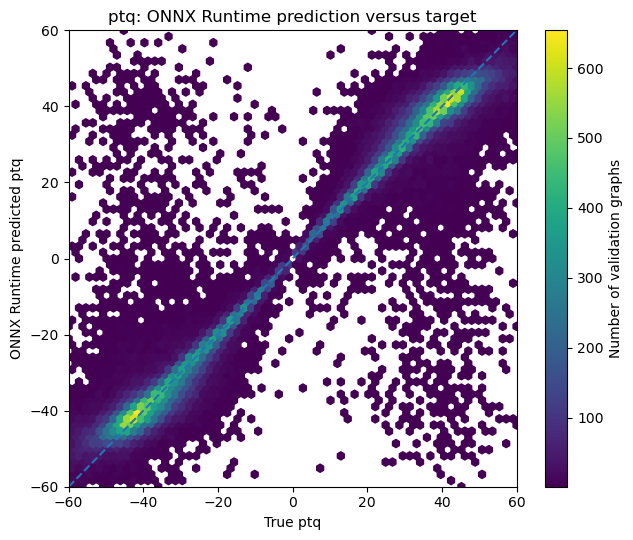

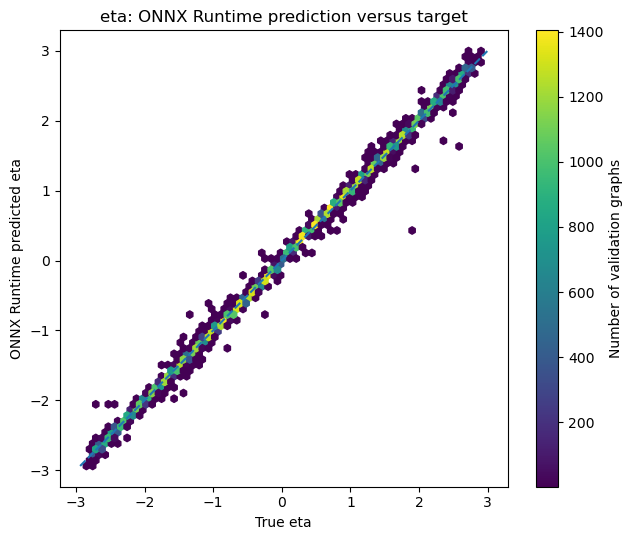

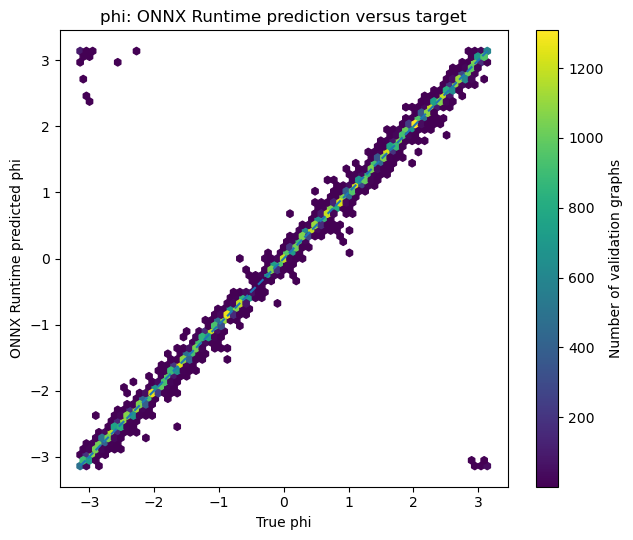

In [6]:
HEXBIN_GRIDSIZE = 65

for col, name in enumerate(target_names):
    true_values = y_true[plot_idx, col]
    pred_values = y_pred[plot_idx, col]

    if name == "ptq":
        # Constrain the *bin construction* to the requested physical range.
        # Axis limits alone only crop the rendered figure; `extent` makes the
        # hexagons span exactly [-90, 90] on both axes.  The mask also prevents
        # out-of-range points from being accumulated into edge bins.
        low, high = PT_PLOT_RANGE
        in_range = (
            (true_values >= low)
            & (true_values <= high)
            & (pred_values >= low)
            & (pred_values <= high)
        )
        hexbin_x = true_values[in_range]
        hexbin_y = pred_values[in_range]
        if hexbin_x.size == 0:
            raise RuntimeError(
                "No ptq validation points lie within PT_PLOT_RANGE on both axes; "
                "cannot build the requested hexbin."
            )
    else:
        hexbin_x = true_values
        hexbin_y = pred_values
        low = float(min(hexbin_x.min(), hexbin_y.min()))
        high = float(max(hexbin_x.max(), hexbin_y.max()))

    # `extent` controls the hexagonal bin edges, unlike xlim/ylim which only
    # crop a hexbin that has already been calculated over an automatic range.
    plt.figure(figsize=(6.5, 5.5))
    plt.hexbin(
        hexbin_x,
        hexbin_y,
        gridsize=HEXBIN_GRIDSIZE,
        extent=(low, high, low, high),
        mincnt=1,
    )
    plt.plot([low, high], [low, high], linestyle="--")
    plt.xlabel(f"True {name}")
    plt.ylabel(f"ONNX Runtime predicted {name}")
    plt.title(f"{name}: ONNX Runtime prediction versus target")
    if name == "ptq":
        plt.xlim(low, high)
        plt.ylim(low, high)
    plt.colorbar(label="Number of validation graphs")
    plt.tight_layout()
    plt.show()


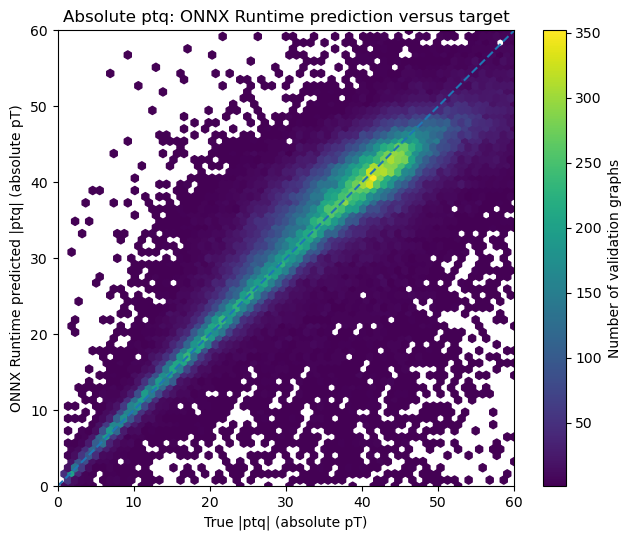

Absolute-ptq plot: 94,379 graphs within [-60, 60] for both target and prediction.


In [ ]:
# Absolute ptq (absolute pT): ONNX Runtime prediction versus target.
# This uses the same cached validation sample and the same physical selection as
# the signed-ptq hexbin above: both target and prediction must lie in PT_PLOT_RANGE.
if "ptq" not in target_names:
    raise KeyError("The cached target_names do not contain 'ptq'.")

ptq_col = target_names.index("ptq")
true_ptq = y_true[plot_idx, ptq_col]
pred_ptq = y_pred[plot_idx, ptq_col]
ptq_low, ptq_high = PT_PLOT_RANGE

ptq_in_range = (
    (true_ptq >= ptq_low)
    & (true_ptq <= ptq_high)
    & (pred_ptq >= ptq_low)
    & (pred_ptq <= ptq_high)
)
true_abs_ptq = np.abs(true_ptq[ptq_in_range])
pred_abs_ptq = np.abs(pred_ptq[ptq_in_range])

if true_abs_ptq.size == 0:
    raise RuntimeError(
        "No p_t validation points lie within PT_PLOT_RANGE on both axes; "
        "cannot plot absolute p_t."
    )

ABS_PT_PLOT_RANGE = (0.0, max(abs(ptq_low), abs(ptq_high)))
abs_low, abs_high = ABS_PT_PLOT_RANGE

plt.figure(figsize=(6.5, 5.5))
plt.hexbin(
    true_abs_ptq,
    pred_abs_ptq,
    gridsize=HEXBIN_GRIDSIZE,
    extent=(abs_low, abs_high, abs_low, abs_high),
    mincnt=1,
)
plt.plot([abs_low, abs_high], [abs_low, abs_high], linestyle="--")
plt.xlabel("True |p_t|")
plt.ylabel("ONNX Runtime predicted |p_t|")
plt.title("Absolute p_t: ONNX Runtime prediction versus target")
plt.xlim(abs_low, abs_high)
plt.ylim(abs_low, abs_high)
plt.colorbar(label="Number of validation graphs")
plt.tight_layout()
plt.show()

print(
    f"Absolute-p_t plot: {true_abs_ptq.size:,} graphs within "
    f"[{ptq_low:g}, {ptq_high:g}] for both target and prediction."
)


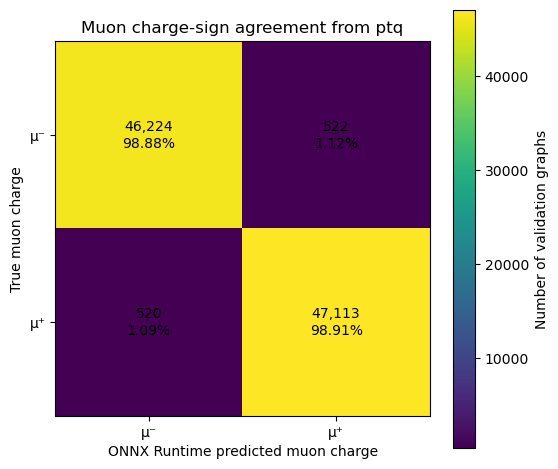

Charge-sign accuracy: 98.8959%
Graphs in charge-sign plot: 94,379
Rows show true muon charge; annotations are count and percentage within that true-charge row.


In [9]:
# Muon charge-sign agreement from signed ptq.
# Use the identical in-range ptq population as the signed and absolute-ptq plots.
# Muons have charge q = -1 or q = +1 only: an exactly-zero target or prediction
# is treated as an invalid input to this two-class charge-sign matrix.
if "ptq_in_range" not in globals():
    ptq_col = target_names.index("ptq")
    true_ptq = y_true[plot_idx, ptq_col]
    pred_ptq = y_pred[plot_idx, ptq_col]
    ptq_low, ptq_high = PT_PLOT_RANGE
    ptq_in_range = (
        (true_ptq >= ptq_low)
        & (true_ptq <= ptq_high)
        & (pred_ptq >= ptq_low)
        & (pred_ptq <= ptq_high)
    )

selected_true_ptq = true_ptq[ptq_in_range]
selected_pred_ptq = pred_ptq[ptq_in_range]
finite_charge = np.isfinite(selected_true_ptq) & np.isfinite(selected_pred_ptq)
selected_true_ptq = selected_true_ptq[finite_charge]
selected_pred_ptq = selected_pred_ptq[finite_charge]

if selected_true_ptq.size == 0:
    raise RuntimeError("No finite, in-range ptq values are available for the charge-sign plot.")

zero_true = int(np.count_nonzero(selected_true_ptq == 0.0))
zero_pred = int(np.count_nonzero(selected_pred_ptq == 0.0))
if zero_true or zero_pred:
    raise RuntimeError(
        "Muon charge has only two physical classes, q=-1 and q=+1. "
        f"Found {zero_true} zero target ptq value(s) and {zero_pred} zero ONNX prediction(s) "
        "in the selected population; inspect these values rather than assigning them a charge."
    )

# The zero-value guard above makes this an unambiguous two-class conversion.
charge_true = np.where(selected_true_ptq < 0.0, -1, 1).astype(np.int8)
charge_pred = np.where(selected_pred_ptq < 0.0, -1, 1).astype(np.int8)

sign_values = np.array([-1, 1], dtype=np.int8)
sign_labels = ["μ⁻", "μ⁺"]
charge_counts = np.zeros((len(sign_values), len(sign_values)), dtype=np.int64)
for true_row, true_sign in enumerate(sign_values):
    for pred_col, pred_sign in enumerate(sign_values):
        charge_counts[true_row, pred_col] = np.count_nonzero(
            (charge_true == true_sign) & (charge_pred == pred_sign)
        )

charge_sign_accuracy = float(np.mean(charge_true == charge_pred))

fig, ax = plt.subplots(figsize=(5.7, 5.0))
image = ax.imshow(charge_counts)
for row in range(charge_counts.shape[0]):
    row_total = int(charge_counts[row].sum())
    for col in range(charge_counts.shape[1]):
        count = int(charge_counts[row, col])
        row_fraction = 100.0 * count / row_total if row_total else 0.0
        ax.text(col, row, f"{count:,}\n{row_fraction:.2f}%", ha="center", va="center")

ax.set_xticks(np.arange(len(sign_labels)), labels=sign_labels)
ax.set_yticks(np.arange(len(sign_labels)), labels=sign_labels)
ax.set_xlabel("ONNX Runtime predicted muon charge")
ax.set_ylabel("True muon charge")
ax.set_title("Muon charge-sign agreement from ptq")
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Number of validation graphs")
fig.tight_layout()
plt.show()

print(f"Charge-sign accuracy: {charge_sign_accuracy:.4%}")
print(f"Graphs in charge-sign plot: {charge_true.size:,}")
print("Rows show true muon charge; annotations are count and percentage within that true-charge row.")

### ONNX Runtime residual distributions


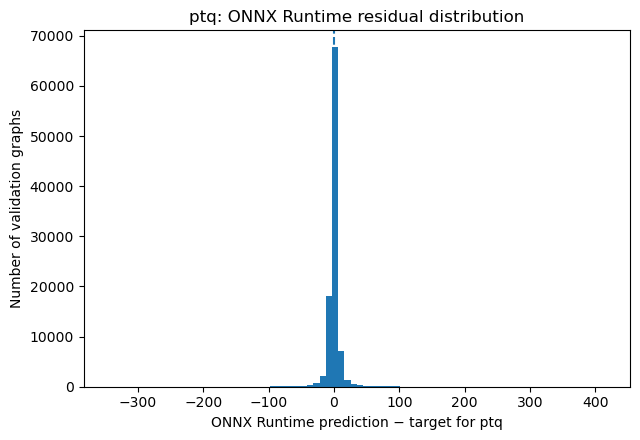

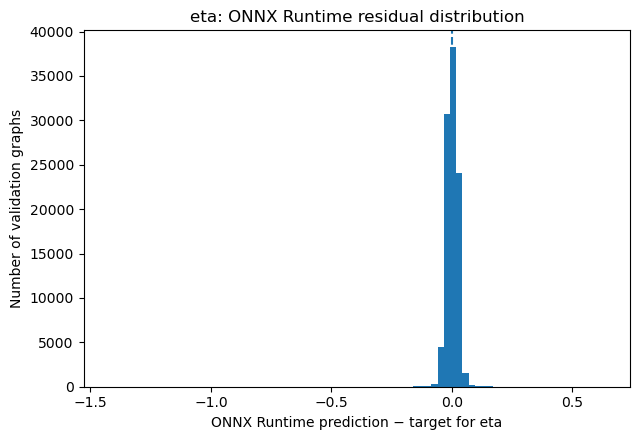

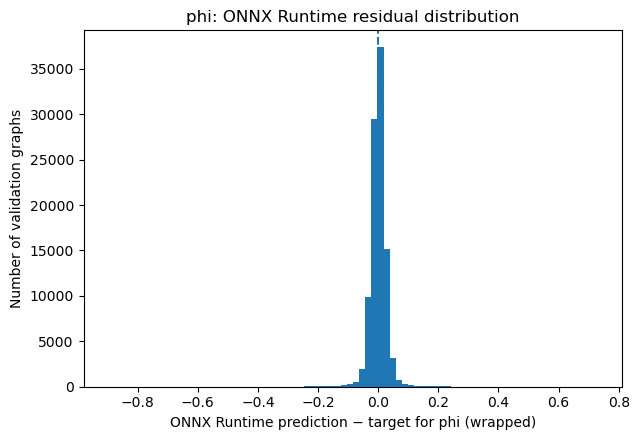

In [11]:
for col, name in enumerate(target_names):
    plt.figure(figsize=(6.5, 4.5))
    plt.hist(residual[plot_idx, col], bins=80)
    plt.axvline(0.0, linestyle="--")
    suffix = " (wrapped)" if name == "phi" else ""
    plt.xlabel(f"ONNX Runtime prediction − target for {name}{suffix}")
    plt.ylabel("Number of validation graphs")
    plt.title(f"{name}: ONNX Runtime residual distribution")
    plt.tight_layout()
    plt.show()


### ONNX Runtime absolute error versus target value

The point at each x-position is the mean absolute error within a quantile bin of the true target. This can reveal target-dependent degradation that a global MAE can hide. For `ptq`, only the displayed target range −90 to 90 is plotted.


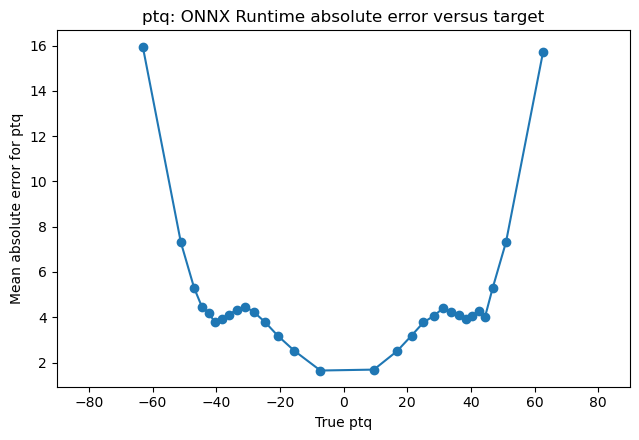

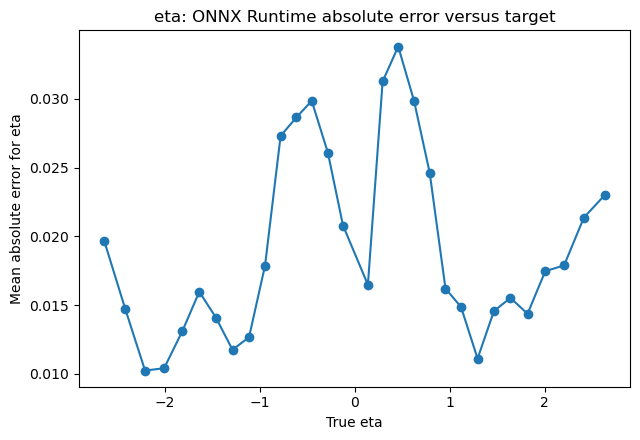

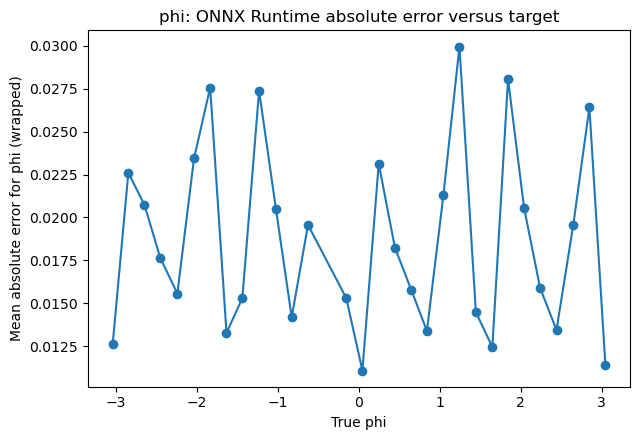

In [12]:
def binned_mean_absolute_error(
    x: np.ndarray,
    ae: np.ndarray,
    bins: int = 30,
) -> Tuple[np.ndarray, np.ndarray]:
    order = np.argsort(x)
    chunks = np.array_split(order, min(bins, len(order)))
    x_center = np.asarray([np.median(x[idx]) for idx in chunks if len(idx)])
    mean_ae = np.asarray([np.mean(ae[idx]) for idx in chunks if len(idx)])
    return x_center, mean_ae


for col, name in enumerate(target_names):
    selected_idx = plot_idx
    if name == "ptq":
        pt_mask = (
            (y_true[plot_idx, col] >= PT_PLOT_RANGE[0])
            & (y_true[plot_idx, col] <= PT_PLOT_RANGE[1])
        )
        selected_idx = plot_idx[pt_mask]

    x_center, mean_ae = binned_mean_absolute_error(
        y_true[selected_idx, col],
        abs_error[selected_idx, col],
        bins=30,
    )
    plt.figure(figsize=(6.5, 4.5))
    plt.plot(x_center, mean_ae, marker="o")
    plt.xlabel(f"True {name}")
    ylabel = f"Mean absolute error for {name}"
    if name == "phi":
        ylabel += " (wrapped)"
    plt.ylabel(ylabel)
    plt.title(f"{name}: ONNX Runtime absolute error versus target")
    if name == "ptq":
        plt.xlim(*PT_PLOT_RANGE)
    plt.tight_layout()
    plt.show()
